# Assignment 2: Molecular Dynamics of n-Pentane

**6EMA02 Particle-based Simulations, 2026-2027 edition**
United-atom force field · liquid n-pentane · conformers and diffusion

## How this assignment is assessed: read this first

This notebook is both the assignment text and your report. Task cells
(like this one) are the assignment text and are marked read-only. Jupyter
enforces that; some editors (VS Code among them) do not, so simply leave
them untouched either way: hand-ins are checked against the released
notebook, and modified task cells are flagged. You write your answers in
the cells below each task and hand in this same notebook, **executed**,
together with an HTML export, your code, and the data files the notebook
loads (layout at the end of this notebook).

Your report is **not graded on its content**. Its result is determined in
the individual oral examination at the end of the quartile: the exam is a
conversation about *your* code and *your* results, with this notebook on
screen. Write it as your defence dossier: concise, bullet answers are
fine, every claim something you can stand behind. A report you never hand
in scores 0 for its weight in the final grade; a handed-in report's
result *is* your oral grade.

**AI and sources.** You may use AI assistants (ChatGPT, Claude, Copilot,
…) freely in this course, for code, analysis, and text. Declare the use
briefly in the *Sources* section below, along with any other external
sources: anything in your submission (code, text, data, results) that
your group did not produce itself. Declared sources are never penalised:
nobody grades the text of your report or the style of your code. The oral
examination assesses what *you* understand about the simulation you hand
in. Anything in your submission is fair game, and "we didn't write that
part" is not an available answer. Presenting undeclared external work as
your own is academic misconduct and is treated as such.

## Group

- **Group ID:** 5
- **Members:** Olivier Jakub Toczyski (), Thomas Dadikozyan (student ID)

## The physics: what molecular dynamics does

Molecular dynamics answers a simple question with a lot of consequences:
if we knew the force on every atom, and we integrated Newton's equations
of motion for all of them, what would the material do?

The machinery is exactly what you built in A1. Positions and velocities
evolve under

$$m_i \frac{\mathrm{d}^2 \mathbf{r}_i}{\mathrm{d}t^2} = \mathbf{F}_i =
-\nabla_i U(\mathbf{r}_1, \ldots, \mathbf{r}_N),$$

integrated with velocity-Verlet. What changes is the potential energy
$U$, and the consequences of that change reach into every part of the
program:

- **The interactions are short ranged.** Gravity reaches across the solar
  system, so A1 could afford all $N(N-1)/2$ pairs. The Lennard-Jones
  interaction is negligible beyond a few molecular diameters, so we cut
  it off and only ever look at nearby pairs. That is what the cell-linked
  list and Verlet neighbour list in the provided code are for: they turn
  an $O(N^2)$ force evaluation into $O(N)$.
- **The system is periodic.** A few thousand molecules in a box with
  walls would be almost all surface. Periodic boundary conditions with
  the minimum-image convention give a bulk liquid instead.
- **The molecules have internal structure.** Besides the non-bonded
  interactions there are bonds, angles and torsions, which is where the
  chemistry of pentane enters.
- **Temperature is a thing you control.** A thermostat lets you sample a
  constant-temperature (NVT) ensemble instead of constant energy (NVE).

Why any of this is worth doing: from the trajectory you can measure
quantities that are hard or impossible to get any other way. In this
assignment you measure two of them, each testing a different layer of the
simulation. The conformer populations test the free-energy landscape of a
single molecule, and reveal the **pentane effect**, a genuinely subtle
piece of chemistry. The mean-squared displacement gives a transport
coefficient, the self-diffusion coefficient, through the Einstein
relation

$$\left\langle |\mathbf{r}_\mathrm{cm}(t) - \mathbf{r}_\mathrm{cm}(0)|^2
\right\rangle \xrightarrow{\ t\ \text{large}\ } 6 D t .$$

## The model: a united-atom force field for n-pentane

**The molecule.** n-Pentane is
$\mathrm{CH}_3$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_3$.
We do not simulate the hydrogens. In a **united-atom** model each
$\mathrm{CH}_3$ or $\mathrm{CH}_2$ group is one interaction site with the
mass of the whole group. Two reasons: it removes two thirds of the sites,
and, more importantly, it removes the fastest motion in the system. A
C-H bond vibrates with a period of about 10 fs, which would force a time
step of roughly 0.1 fs; without hydrogens, 1 fs is enough.

Each molecule therefore has 5 sites, **4 bonds, 3 angles and 2
dihedrals** ($\phi_1$ over atoms 1-2-3-4 and $\phi_2$ over atoms
2-3-4-5). The two dihedrals share three atoms, which is what makes their
statistics *coupled* rather than independent, and that coupling is the
subject of task C2.

**State point:** density $\rho = 626\ \mathrm{kg/m^3}$ and
$T = 293$ K, which is liquid pentane at ambient conditions.

### Non-bonded: Lennard-Jones

$$U_{\mathrm{LJ}}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} -
\left(\frac{\sigma}{r}\right)^{6}\right] - U_{\mathrm{LJ}}(r_{\text{cut}})
\quad \text{for } r \le r_{\text{cut}},$$

and zero beyond. Use $r_\text{cut} = 14$ Å. The $r^{-6}$ term is the
attractive dispersion interaction that holds the liquid together; the
$r^{-12}$ term is the repulsion that keeps sites apart. Subtracting
$U_{\mathrm{LJ}}(r_\text{cut})$ shifts the potential to zero at the
cut-off, so that no energy jump occurs when a pair crosses it.

| Site | $\epsilon/k_B$ (K) | $\sigma$ (Å) | mass (amu) |
|------|-----|------|------|
| $\mathrm{CH}_3$ | 98.0 | 3.75 | 15.035 |
| $\mathrm{CH}_2$ | 46.0 | 3.95 | 14.027 |

Cross terms follow the Lorentz-Berthelot mixing rules,
$\sigma_{ij} = \tfrac12(\sigma_i + \sigma_j)$ and
$\epsilon_{ij} = \sqrt{\epsilon_{ii}\,\epsilon_{jj}}$.

**Exclusions.** Within a molecule, the 1-2, 1-3 and 1-4 pairs must
**not** interact through Lennard-Jones: their geometry is already fixed
by the bond, angle and torsion terms, and counting both would be double
counting. The **1-5 pair does interact**, and that single interaction,
between the two end groups, is what makes the pentane effect of task C2
appear.

### Bonded terms

$$U_{\mathrm{bond}}(r) = \tfrac12 k_b (r - r_0)^2, \qquad
r_0 = 1.54\ \text{Å}, \quad k_b/k_B = 3.19\times10^{5}\ \text{K/Å}^2,$$

$$U_{\mathrm{angle}}(\theta) = \tfrac12 k_\theta (\theta - \theta_0)^2,
\qquad \theta_0 = 114^\circ, \quad
k_\theta/k_B = 6.25\times10^{4}\ \text{K rad}^{-2}.$$

For each of the two dihedral angles, the Ryckaert-Bellemans torsion

$$U_{\mathrm{tors}}(\phi) = c_0 + c_1\cos\phi + c_2\cos^2\phi +
c_3\cos^3\phi,$$

$$c_0/k_B = 1010.0\ \text{K},\quad c_1/k_B = -2018.9\ \text{K},\quad
c_2/k_B = 136.4\ \text{K},\quad c_3/k_B = 3165.3\ \text{K}.$$

This has its global minimum at $\phi = 180^\circ$ (*trans*) and local
minima near $\pm 60^\circ$ (*gauche*), separated by barriers of several
$k_BT$. Those barriers are the reason conformer statistics converge
slowly: a molecule sits in one state for a long time and flips rarely, so
what you are sampling is a **rare event**, which task C2 asks you to
think about quantitatively.

A force field like this one is *empirical*: the functional forms are
chosen for convenience and the parameters are fitted, here to
thermodynamic data for alkanes. Nothing guarantees it reproduces a
property it was not fitted to. That is the difference between
verification (Part B: does my code implement this model correctly?) and
validation (Part C: does this model describe real pentane?).

## The code, and your working environment

The starting code is `MD_student_v7.0.0.zip` under Files ▸ Code. It is a
working Lennard-Jones molecular dynamics program: your job is to extend
it into a pentane simulator. Unpacking it gives you a folder
`MD_student_v7.0.0`; rename that to `code/` in your working directory, so
that the paths in this notebook and in the hand-in layout line up.

**The files.** `main.c` holds the whole control flow and is the place to
start reading. Then: `constants.h` (compile-time constants),
`structs.h` (all data types), `memory.c` (allocation and freeing),
`setparameters.c` (**the only place run configuration lives**: there are
no input files, you recompile to change a run), `random.c`,
`initialise.c` (initial positions, velocities, topology), `nbrlist.c`
(cell-linked list and Verlet neighbour list), `forces.c` (your main work
site), `dynamics.c` (the velocity-Verlet halves, boundary conditions,
thermostat), `fileoutput.c` (`.pdb` trajectories and restart files), and
`force_test.c` (the finite-difference force and virial checker you will
use in B3 and B5).

**The task list.** Open `html/index.html` from the zip: the Doxygen
documentation of the code has a generated *todo list* with every
`\todo` marker you must fill in. Treat it as the checklist for Part B.

**Build and run** (Linux and macOS; on Windows use MSYS2 or the provided
VS Code tasks):

```
gcc -O3 *.c -o md -lm                      # production
gcc -g -Wall -Wextra *.c -o md_debug -lm   # debugging
./md > run.csv
```

**House rules when extending.** New functions get a prototype in the
matching `.h`. New per-particle arrays are added to a struct in
`structs.h`, allocated in `alloc_memory` and freed in `free_memory`.
Internal units are the reduced units of task A1, not SI.

**Visualisation.** The code writes `.pdb` trajectories; open them in
OVITO (ovito.org). Look at your system early and often: most bugs in
this assignment are visible before they are measurable.

**Python environment.** The same `pbs-env` you set up for A1, from
`requirements.txt` (Files ▸ Assignments); the Canvas page *Working on the
assignments* has the details. The helper scripts are unchanged:
`nb2html.py` writes the HTML you hand in, `check_my_submission.py`
checks your zip before you submit it.

## Code map

All links are relative and point to files inside the zip.

| Task | File / function(s) | Data files |
|------|--------------------|------------|
| A1 units | no code (derivation in the A1 answer) | - |
| A2 bonded forces (derivation) | [`calculate_forces_bond`, `calculate_forces_angle`, `calculate_forces_dihedral`](code/forces.c) | - |
| B1 I/O | [`main`](code/main.c) | [test.csv](data/test.csv) |
| B2 types + LJ | [`initialise_types`, `initialise_velocities`](code/initialise.c), [`update_velocities_half_dt`](code/dynamics.c), [`calculate_forces_nb`](code/forces.c) | - |
| B3 non-bonded tests | [`forces_test`, `virial_test`](code/force_test.c) | [FD test](data/b3_force_test.txt), [NVE 1 fs](data/b3_nve_1fs.csv), [NVE 0.5 fs](data/b3_nve_05fs.csv), [type temperatures](data/b3_type_temperature.csv) |
| B4 bonded forces | [`calculate_forces_bond`, `calculate_forces_angle`, `calculate_forces_dihedral`](code/forces.c) | - |
| B5 bonded tests | [`check_torsion_force_and_torque`](code/main.c) | [FD tests](data/b5_force_tests.txt), [NVE, one molecule](data/b5_nve.csv), [thermalisation](data/b5_thermalisation.csv) |
| B6 initialisation | [`initialise_positions`, `initialise_velocities`](code/initialise.c) | [rendering](code/b6_render.png), [start configuration](code/restart_files/restart_b6_start.dat) |
| B7 full-system NVE | [`main`](code/main.c) | [NVE run](data/b7_nve.csv) |
| B8 thermostat | [`thermostat`](code/dynamics.c) | - |
| B9 thermostat tests | [`thermostat`](code/dynamics.c) | [tau = 0.01 ps](data/b9_nvt_tau001.csv), [tau = 1 ps](data/b9_nvt_tau1.csv) |
| C1 conformer analysis | not done yet | - |
| C2 MSD and diffusion | not done yet | - |

## Sources

- **AI tools we declared in the original report:** OpenAI Codex, for B1-B3. We used it to review our typed-mass and LJ code, to analyse saved CSV and force-test output, and to draft B1-B3 text and plots.
- **AI used for this rewrite:** Claude (Claude Code) rewrote our answer text as bullets and restructured our analysis code cells. The numbers and claims come from our original notebook.
- **Other external sources:** the course-supplied MD starter code and the assignment text.
- **Our analysis code** is in the notebook cells below. There is no separate `analyse_b123.py` file.
- **Still to fill in:** which AI tools, if any, we used for B4-B9. The original report did not record this.

## Build & run log

**Compile check**
- Date and system: 2026-09-29, Windows with MSYS2 GCC.
- Command, run from the notebook directory: `gcc -O3 -Wall -Wextra code/*.c -o md_b123_check.exe -lm`.
- Result: it compiled in about 2 s.
- Warnings: unfinished bonded routines (at that time) and a `%lu`/`size_t` format in the XYZ writer.

**Analysis cells**
- They run in our `pbs-env` Python environment.
- They only read saved files from `data/`. The notebook does not start any simulation.

**NVE runs of B3** (50 ps each, checked against the CSV files)

| Time step | Steps | Output every |
|---|---:|---:|
| 1 fs | 50,000 | 10 steps |
| 0.5 fs | 100,000 | 20 steps |

**Not recorded**
- The exact commands, wall times and parameter snapshots of the earlier runs were not saved.
- We do not reconstruct them here.

**How to re-run a simulation**
1. Edit `code/setparameters.c`. It is the only place where the run configuration lives.
2. From `code/`, build with `gcc -O3 *.c -o md -lm`.
3. Run `./md > ../data/NEW_RUN.csv`. In PowerShell: `./md.exe | Out-File -Encoding utf8 ../data/NEW_RUN.csv`.
4. Use a new output name each time, and archive the parameters of the run.
5. Restart and trajectory paths are relative to `code/`.

**Encoding**
- PowerShell redirection writes UTF-16 files. This is why our loaders read the CSV files as UTF-16.

In [1]:
# Shared imports, constants and two small helper functions for the analysis cells below.
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PS_PER_TIME_UNIT = 1.0967   # one internal time unit in ps (t0 from A1)
T_TARGET = 293.0            # target temperature in K
FD_TOL = 5e-5               # accepted relative tolerance of the finite-difference test (B3)


def load_csv(path):
    """Read a CSV file. Files redirected from PowerShell are UTF-16."""
    try:
        return pd.read_csv(path)
    except UnicodeError:
        return pd.read_csv(path, encoding="utf-16")


def energy_drift(time, etot):
    """Fit Etot = slope * time + intercept.

    slope           -> systematic drift
    residual        -> what is left after removing the line (the bounded oscillation)
    rel_oscillation -> half peak-to-peak of the residual, divided by |mean Etot|
    """
    slope, intercept = np.polyfit(time, etot, 1)
    mean = np.mean(etot)
    residual = etot - (slope * time + intercept)
    half_range = 0.5 * (residual.max() - residual.min())
    return {
        "mean": mean,
        "slope": slope,
        "rel_drift": slope / abs(mean),
        "residual": residual,
        "rel_oscillation": half_range / abs(mean),
    }

## Part A: Modeling

*In the oral you should be able to:* state your unit system and convert
any quantity in this notebook to SI; derive each bonded force from its
potential; explain why the four torsion forces sum to zero and exert no
net torque.

### A1) Units

It is common practice to introduce non-standard units in simulations. In
your code, use Kelvin for the energy scale (that is, the energy unit is
$k_B \times 1$ K), Å for distances, and atomic mass units (amu) for
masses. The time unit follows from these.

Deliver: the derivation of the time unit, its value in SI, and the time
step of 1 fs expressed in internal units. State also the internal-unit
values you will use for $\epsilon$, $\sigma$, $k_b$ and $k_\theta$, and
one sanity check that your conversion is right (for example, the thermal
velocity of a $\mathrm{CH}_2$ site at 293 K, in both unit systems).

### Answer A1: Units

#### Base units
- We choose energy, length and mass as the base units. Every other unit follows from them.
- A quantity in internal units is its SI value divided by the unit. A star ($^*$) marks an internal value.

| Quantity | Unit | SI value |
|---|---|---|
| Energy | $E_0 = k_B \times 1\ \mathrm{K}$ | $1.380649\times10^{-23}$ J |
| Length | $L_0 = 1$ Å | $10^{-10}$ m |
| Mass | $M_0 = 1$ amu | $1.66054\times10^{-27}$ kg |

#### Time unit
- Energy has dimensions mass × length² / time², so the three units must satisfy

$$E_0 = \frac{M_0 L_0^2}{t_0^2}.$$

- Solving for the time unit:

$$t_0 = \sqrt{\frac{M_0 L_0^2}{E_0}} = \sqrt{\frac{(1.66054\times10^{-27})(10^{-10})^2}{1.380649\times10^{-23}}} \approx 1.0967\times10^{-12}\ \mathrm{s} = 1.0967\ \mathrm{ps}.$$

- **Why?** Once energy, length and mass are fixed, time is no longer free. It is the only unit that makes $E = M L^2/t^2$ hold.
- The 1 fs time step in internal units is

$$\Delta t^* = \frac{10^{-15}\ \mathrm{s}}{1.0967\times10^{-12}\ \mathrm{s}} \approx 9.1184\times10^{-4}.$$

- Handy conversion: $1\ \mathrm{ps} = 0.9118$ internal time units.

#### Force-field parameters in internal units
- $\epsilon/k_B$ is given in kelvin and $\sigma$ in Å. These are already our base units, so the numbers carry over unchanged.

| Site type | $\epsilon^*$ | $\sigma^*$ | $m^*$ |
|-----------|-------------:|-----------:|------:|
| CH$_3$ | 98.0 | 3.75 | 15.035 |
| CH$_2$ | 46.0 | 3.95 | 14.027 |

- For a mixed CH$_3$-CH$_2$ pair, Lorentz-Berthelot gives

$$\epsilon_{32}^* = \sqrt{98.0 \times 46.0} \approx 67.1416, \qquad \sigma_{32}^* = \frac{3.75 + 3.95}{2} = 3.85.$$

| Parameter | Internal value | Reason |
|---|---:|---|
| $k_b^*$ | $3.19\times10^{5}$ | energy / length², so $k_b L_0^2 / E_0$ is just the number in K/Å² |
| $r_0^*$ | 1.54 | length in Å |
| $k_\theta^*$ | $6.25\times10^{4}$ | energy per rad²; the angle must be in **radians** |
| $\theta_0$ | 1.98968 rad | $114^\circ \times \pi/180$ |
| $r_\mathrm{cut}^*$ | 14 | length in Å |

#### Sanity check: thermal speed of a CH$_2$ site at 293 K
- We use the 3D root-mean-square speed.

$$v_\mathrm{rms} = \sqrt{\frac{3 k_B T}{m}}.$$

- **Route 1, in SI.** The site mass is $m = 14.027 \times 1.66054\times10^{-27} = 2.32924\times10^{-26}$ kg, so

$$v_\mathrm{rms} = \sqrt{\frac{3(1.380649\times10^{-23})(293)}{2.32924\times10^{-26}}} \approx 721.8\ \mathrm{m/s}.$$

- **Route 2, in internal units.** Here $k_B T/E_0 = 293$ and $m^* = 14.027$, so

$$v^*_\mathrm{rms} = \sqrt{\frac{3(293)}{14.027}} \approx 7.9161.$$

- The velocity unit is $v_0 = L_0/t_0 = 10^{-10}/1.0967\times10^{-12} \approx 91.184$ m/s. Converting back:

$$7.9161 \times 91.184 \approx 721.8\ \mathrm{m/s}.$$

- **Conclusion:** both routes give 721.8 m/s, so our conversion is consistent.

### A2) Bonded forces

From the expressions for the bond, angle, and torsion potentials, derive
the corresponding forces. Express them in terms of the bond vectors
$\mathbf{r}_{ij}$, $\mathbf{r}_{kj}$, and $\mathbf{r}_{kl}$ as defined in
`forces.c`.

Deliver, for each of the three terms: the force on every participating
atom, and one sentence on how the expression behaves in an obvious limit
(for instance at the potential minimum). State explicitly why the four
torsion forces sum to zero and carry no net torque, and describe the
numerical test that would confirm both properties on your own
implementation.

### Answer A2: Bonded forces

#### Starting point
- The force on an atom is minus the gradient of the energy, so it points towards lower energy.

$$\boxed{\mathbf F_s = -\nabla_{\mathbf r_s} U}$$

- **Method for all three terms:** write $U$ as a function of one scalar (bond length, angle, or $\cos\phi$). Then use the chain rule to get from that scalar to the atom positions.
- In `forces.c` the bond vectors are the following. The minimum-image convention is already applied to them.

| Vector | Definition | Points from |
|---|---|---|
| $\mathbf r_{ij}$ | $\mathbf r_i - \mathbf r_j$ | $j$ to $i$ |
| $\mathbf r_{kj}$ | $\mathbf r_k - \mathbf r_j$ | $j$ to $k$ |
| $\mathbf r_{kl}$ | $\mathbf r_k - \mathbf r_l$ | $l$ to $k$ |

- The forces below belong to **one** interaction. In the code they are added to the total force on each atom.

---
#### 1. Bond stretch (atoms $i$ and $j$)

**Setup.** Let $\mathbf a = \mathbf r_{ij}$ and $r = |\mathbf a|$. The energy is

$$U_b = \tfrac12 k_b (r - r_0)^2.$$

It penalises both stretching and compression.

**Slope of the energy with respect to the length:**

$$\frac{\mathrm dU_b}{\mathrm dr} = k_b (r - r_0).$$

**Slope of the length with respect to the position of atom $i$:**

$$\nabla_{\mathbf r_i} r = \frac{\mathbf a}{r}.$$

- **Why?** Moving atom $i$ away from $j$ by a small step $\mathrm d\mathbf s$ changes the length by $\mathrm dr = (\mathbf a/r)\cdot\mathrm d\mathbf s$. Only the component of the step along the bond matters, so the gradient is the unit vector along the bond.

**Chain rule:**

$$\boxed{\mathbf F_i = -k_b (r - r_0)\,\frac{\mathbf a}{r}}, \qquad \boxed{\mathbf F_j = -\mathbf F_i}.$$

- **Why $\mathbf F_j = -\mathbf F_i$?** The energy only depends on $\mathbf r_i - \mathbf r_j$. Moving $j$ by $\mathrm d\mathbf s$ has exactly the opposite effect of moving $i$ by $\mathrm d\mathbf s$.
- **Limit check:** at $r = r_0$ both forces are zero. A stretched bond pulls the atoms together, and a compressed bond pushes them apart.

---
#### 2. Angle bend (atoms $i$, $j$, $k$, with $j$ in the middle)

**Setup.** Let $\mathbf a = \mathbf r_{ij}$, $\mathbf b = \mathbf r_{kj}$, $a = |\mathbf a|$, $b = |\mathbf b|$. The angle comes from the dot product:

$$q = \cos\theta = \frac{\mathbf a \cdot \mathbf b}{a\,b}, \qquad U_\theta = \tfrac12 k_\theta (\theta - \theta_0)^2.$$

**Chain of dependence.** Positions change the bond vectors. The bond vectors change $q$, then $\theta$, then $U$. So

$$\mathbf F_i = -\frac{\mathrm dU_\theta}{\mathrm d\theta}\,\frac{\mathrm d\theta}{\mathrm dq}\,\nabla_{\mathbf r_i} q.$$

- **Why go through $q$?** A dot product is easy to differentiate with respect to vectors. $\theta$ itself is not.

**The two scalar derivatives:**

$$\frac{\mathrm dU_\theta}{\mathrm d\theta} = k_\theta(\theta - \theta_0), \qquad \frac{\mathrm d\theta}{\mathrm dq} = -\frac{1}{\sin\theta}.$$

- **Why?** $\theta = \arccos q$, and the derivative of $\arccos q$ is $-1/\sqrt{1-q^2} = -1/\sin\theta$.

**Gradient of $q$.** Moving atom $i$ changes only $\mathbf a$. Moving atom $k$ changes only $\mathbf b$. The product rule on $q = (\mathbf a\cdot\mathbf b)/(ab)$ gives

$$\nabla_{\mathbf r_i} q = \frac{\mathbf b}{ab} - q\,\frac{\mathbf a}{a^2}, \qquad \nabla_{\mathbf r_k} q = \frac{\mathbf a}{ab} - q\,\frac{\mathbf b}{b^2}.$$

- **Why two terms?** $q$ depends on $\mathbf a$ in the numerator ($\mathbf a\cdot\mathbf b$) and in the denominator ($a = |\mathbf a|$). The first term is the numerator part. The second term is the denominator part, using $\nabla_{\mathbf a}\, a = \mathbf a/a$.

**Combine.** The minus sign of the force cancels the minus sign of $\mathrm d\theta/\mathrm dq$:

$$\boxed{\mathbf F_i = \frac{k_\theta(\theta - \theta_0)}{\sin\theta}\left(\frac{\mathbf b}{ab} - \cos\theta\,\frac{\mathbf a}{a^2}\right)}$$

$$\boxed{\mathbf F_k = \frac{k_\theta(\theta - \theta_0)}{\sin\theta}\left(\frac{\mathbf a}{ab} - \cos\theta\,\frac{\mathbf b}{b^2}\right)}$$

**Central atom.** Moving $j$ changes both vectors, each with a minus sign ($\mathbf a = \mathbf r_i - \mathbf r_j$ and $\mathbf b = \mathbf r_k - \mathbf r_j$). The result is

$$\boxed{\mathbf F_j = -\mathbf F_i - \mathbf F_k}.$$

- **Why?** Moving all three atoms together changes no angle. So the three forces must add up to zero.

> **Intuition:** the bracket in $\mathbf F_i$ is the part of $\mathbf b/(ab)$ that is perpendicular to $\mathbf a$. So the force on atom $i$ is perpendicular to its own bond. It swings atom $i$ around the central atom and never stretches the bond. The bond-length force is a separate term.

**Limit checks**
- At $\theta = \theta_0$ all three forces are zero.
- $\mathbf F_i \cdot \mathbf a = 0$, because $\dfrac{\mathbf a\cdot\mathbf b}{ab} - \cos\theta = 0$. The force is purely a bending force.
- The formulas need nonzero bond lengths and $0 < \theta < \pi$, and the angle must be in radians.

---
#### 3. Torsion (atoms $i$, $j$, $k$, $l$)

##### 3a. Geometry
- Bond vectors: $\mathbf a = \mathbf r_{ij}$, $\mathbf b = \mathbf r_{kj}$, $\mathbf c = \mathbf r_{kl}$.
- Each plane (atoms $ijk$ and $jkl$) has a normal vector, from a cross product:

$$\mathbf n = \mathbf a \times \mathbf b, \qquad \mathbf m = \mathbf b \times \mathbf c, \qquad N = |\mathbf n|, \quad M = |\mathbf m|.$$

- The torsion angle is the angle between the two planes, which is the angle between their normals:

$$q = \cos\phi = \frac{\mathbf n \cdot \mathbf m}{N\,M}.$$

- With these definitions, trans gives opposite normals. So $q = -1$ and $\phi = \pi$, as the assignment requires.
- **Why $\cos\phi$ and not $\phi$?** The torsion energy is a polynomial in $\cos\phi$. We never need $\phi$ itself, so there is no arccos, no sign ambiguity and no singularity at $0$ or $\pi$.

##### 3b. Slope of the energy
- The energy depends on $\phi$ only through $q$:

$$U_\phi = c_0 + c_1 q + c_2 q^2 + c_3 q^3.$$

- Define its slope with respect to $q$:

$$H = \frac{\mathrm dU_\phi}{\mathrm dq} = c_1 + 2 c_2 q + 3 c_3 q^2.$$

- Then for every atom $s$ the chain rule gives

$$\mathbf F_s = -H\,\nabla_{\mathbf r_s} q.$$

- What remains is the gradient of $q$ with respect to the atom positions.

##### 3c. Gradient of $q$ with respect to the two normals
- $q$ is a normalised dot product of $\mathbf n$ and $\mathbf m$. This is the same form as $\cos\theta$ in the angle case, so the same product rule applies:

$$\mathbf A = \nabla_{\mathbf n} q = \frac{\mathbf m}{NM} - q\,\frac{\mathbf n}{N^2}, \qquad \mathbf B = \nabla_{\mathbf m} q = \frac{\mathbf n}{NM} - q\,\frac{\mathbf m}{M^2}.$$

- $\mathbf A$ and $\mathbf B$ are only intermediate quantities. They are **not** forces.

##### 3d. From the normals to the bond vectors
**Step 1: the total change of $q$.** $q$ depends on two vectors, $\mathbf n$ and $\mathbf m$. For a small change of the atoms, each vector changes a little, and each change moves $q$ by "gradient times change". The two contributions add:

$$\mathrm dq = \mathbf A \cdot \mathrm d\mathbf n + \mathbf B \cdot \mathrm d\mathbf m.$$

> **Intuition:** this is the multivariable chain rule. If a quantity depends on two inputs, its total change is the change caused by the first input plus the change caused by the second. The vectors $\mathbf A$ and $\mathbf B$ are exactly the "sensitivities" of $q$ to $\mathbf n$ and to $\mathbf m$.

**Step 2: how the normals change.** $\mathbf n = \mathbf a \times \mathbf b$ depends on two vectors, so the product rule applies to each factor in turn. The same holds for $\mathbf m$:

$$\mathrm d\mathbf n = \mathrm d\mathbf a \times \mathbf b + \mathbf a \times \mathrm d\mathbf b, \qquad \mathrm d\mathbf m = \mathrm d\mathbf b \times \mathbf c + \mathbf b \times \mathrm d\mathbf c.$$

**Step 3: insert into $\mathrm dq$.**

$$\mathrm dq = \mathbf A\cdot(\mathrm d\mathbf a \times \mathbf b) + \mathbf A\cdot(\mathbf a \times \mathrm d\mathbf b) + \mathbf B\cdot(\mathrm d\mathbf b \times \mathbf c) + \mathbf B\cdot(\mathbf b \times \mathrm d\mathbf c).$$

**Step 4: isolate each $\mathrm d\mathbf a$, $\mathrm d\mathbf b$, $\mathrm d\mathbf c$.** A scalar triple product is unchanged when its three vectors are rotated cyclically: $\mathbf X\cdot(\mathbf Y\times\mathbf Z) = \mathbf Y\cdot(\mathbf Z\times\mathbf X)$. We use it to move every small change to the front:

| Term | After the cyclic swap |
|---|---|
| $\mathbf A\cdot(\mathrm d\mathbf a \times \mathbf b)$ | $\mathrm d\mathbf a \cdot (\mathbf b \times \mathbf A)$ |
| $\mathbf A\cdot(\mathbf a \times \mathrm d\mathbf b)$ | $\mathrm d\mathbf b \cdot (\mathbf A \times \mathbf a)$ |
| $\mathbf B\cdot(\mathrm d\mathbf b \times \mathbf c)$ | $\mathrm d\mathbf b \cdot (\mathbf c \times \mathbf B)$ |
| $\mathbf B\cdot(\mathbf b \times \mathrm d\mathbf c)$ | $\mathrm d\mathbf c \cdot (\mathbf B \times \mathbf b)$ |

**Step 5: collect.** Now $\mathrm dq$ has the form $\mathbf g_a\cdot\mathrm d\mathbf a + \mathbf g_b\cdot\mathrm d\mathbf b + \mathbf g_c\cdot\mathrm d\mathbf c$, with

$$\mathbf g_a = \mathbf b \times \mathbf A, \qquad \mathbf g_b = \mathbf A \times \mathbf a + \mathbf c \times \mathbf B, \qquad \mathbf g_c = \mathbf B \times \mathbf b.$$

- $\mathbf g_a$, $\mathbf g_b$, $\mathbf g_c$ are the gradients of $q$ with respect to $\mathbf a$, $\mathbf b$ and $\mathbf c$. The dot product form shows this, because "change in $q$ = gradient · change in the vector".

##### 3e. From bond-vector gradients to atom gradients
- Each atom position enters only through the bond vectors that contain it:

$$\mathbf a = \mathbf r_i - \mathbf r_j, \qquad \mathbf b = \mathbf r_k - \mathbf r_j, \qquad \mathbf c = \mathbf r_k - \mathbf r_l.$$

- If an atom is the first point of a vector, moving the atom changes that vector by $+\mathrm d\mathbf r$. If it is the second point, the change is $-\mathrm d\mathbf r$.
- If the atom appears in several vectors, we add up the contributions.

| Atom moved | Bond vectors it appears in | Gradient of $q$ |
|---|---|---|
| $i$ | $\mathbf a$ (+) | $\mathbf g_a$ |
| $j$ | $\mathbf a$ (-), $\mathbf b$ (-) | $-\mathbf g_a - \mathbf g_b$ |
| $k$ | $\mathbf b$ (+), $\mathbf c$ (+) | $\mathbf g_b + \mathbf g_c$ |
| $l$ | $\mathbf c$ (-) | $-\mathbf g_c$ |

> **Intuition:** think of it as bookkeeping. To find how $q$ responds to moving atom $k$, list every bond vector that contains $\mathbf r_k$ (here $\mathbf b$ and $\mathbf c$). Each one passes its own sensitivity on, with a plus sign when $k$ is the tip of the vector and a minus sign when $k$ is the tail. Atom $j$ sits at the tail of both $\mathbf a$ and $\mathbf b$, so both signs are negative.

##### 3f. The four torsion forces
- Multiply each gradient by $-H$:

$$\boxed{\mathbf F_i = -H\,\mathbf g_a}, \qquad \boxed{\mathbf F_j = H(\mathbf g_a + \mathbf g_b)},$$

$$\boxed{\mathbf F_k = -H(\mathbf g_b + \mathbf g_c)}, \qquad \boxed{\mathbf F_l = H\,\mathbf g_c}.$$

##### 3g. Limit checks
- At trans the unit normals are opposite, so $\mathbf A = \mathbf B = \mathbf 0$ and all four forces vanish.
- At an interior gauche minimum $H = 0$, so the forces vanish as well.
- The formulas need $N \neq 0$ and $M \neq 0$. A collinear triplet does not define a plane.

---
#### 4. Why the four torsion forces sum to zero and give no net torque

##### Net force
- Add the four results. All terms cancel in pairs:

$$\sum_s \mathbf F_s = -H\mathbf g_a + H(\mathbf g_a + \mathbf g_b) - H(\mathbf g_b + \mathbf g_c) + H\mathbf g_c = \mathbf 0.$$

- **Why?** Moving all four atoms by the same vector changes no bond vector, so $\phi$ and $U$ stay the same. Translation cannot change the energy, so the forces cannot add up to a net push.

> **Intuition:** the torsion is an internal interaction of the four atoms. It can push atoms against each other, but it cannot push the group as a whole. Its centre of mass feels no force from it.

##### Net torque
- Rotate the whole four-atom group rigidly by a small angle. The vector $\delta\boldsymbol\omega$ points along the rotation axis, and its length is the angle. Every atom moves by

$$\delta\mathbf r_s = \delta\boldsymbol\omega \times (\mathbf r_s - \mathbf R),$$

where $\mathbf R$ is a point on the axis.

- A rigid rotation changes no bond length or angle, so $\phi$ and $U$ stay the same. To first order, the energy change is minus the work done by the forces:

$$\delta U = -\sum_s \mathbf F_s \cdot \delta\mathbf r_s = -\delta\boldsymbol\omega \cdot \sum_s (\mathbf r_s - \mathbf R) \times \mathbf F_s.$$

- The second form uses the cyclic swap of the triple product again.
- $\delta U = 0$ holds for every direction of $\delta\boldsymbol\omega$. So the vector it is multiplied with must be zero:

$$\boxed{\sum_s (\mathbf r_s - \mathbf R) \times \mathbf F_s = \mathbf 0}.$$

**What does this sum mean physically?**
- The vector $(\mathbf r_s - \mathbf R)\times\mathbf F_s$ is the torque of force $\mathbf F_s$ about $\mathbf R$. It measures how strongly that force tries to spin the group about $\mathbf R$.
- The total torque is the sum over the four atoms. Zero means the four forces try to spin the group in opposite ways that exactly cancel.
- **Why the origin does not matter:** changing $\mathbf R$ changes the sum by $-\Delta\mathbf R \times \sum_s \mathbf F_s$, which is zero because the net force is zero.

> **Intuition:** the torsion can twist one end of the molecule relative to the other. That changes the shape but it cannot make the molecule spin faster as a whole. So it conserves the total angular momentum, just as the zero net force conserves the total momentum. The same idea also explains why the interaction only depends on the internal angle $\phi$ and not on where or how the four atoms sit in space.

---
#### 5. Numerical tests of our implementation

**Test configuration**
- We use a noncollinear geometry from a **thermalised** single molecule.
- We do not use the freshly built chain. There all bonded forces are zero, so the test would compare round-off with round-off.

**Test 1: net force and net torque of each torsion**

$$\mathbf F_\mathrm{net} = \sum_s \mathbf F_s, \qquad \boldsymbol\tau_\mathrm{net} = \sum_s (\mathbf r_s - \mathbf R)\times\mathbf F_s.$$

- The torque needs positions that are not wrapped by the periodic box. Taking atom $j$ as the origin:

| Atom | Position |
|---|---|
| $j$ | $\mathbf x_j = \mathbf 0$ |
| $i$ | $\mathbf x_i = \mathbf a$ |
| $k$ | $\mathbf x_k = \mathbf b$ |
| $l$ | $\mathbf x_l = \mathbf b - \mathbf c$ |

- Both results must be zero up to round-off.
- We also report them relative to the size of the individual forces:

$$\eta_F = \frac{|\mathbf F_\mathrm{net}|}{\sum_s |\mathbf F_s|}, \qquad \eta_\tau = \frac{|\boldsymbol\tau_\mathrm{net}|}{\sum_s |\mathbf x_s|\,|\mathbf F_s|}.$$

**Test 2: finite differences, for each bonded term separately**
- We displace one atom by a small distance $\delta$ along one axis, with all other coordinates fixed:

$$F^\mathrm{FD}_{s\alpha} = -\frac{U(\mathbf r_s + \delta\mathbf e_\alpha) - U(\mathbf r_s - \delta\mathbf e_\alpha)}{2\delta}.$$

**What each test proves**

| Test | What it proves |
|---|---|
| Net force and torque | the torsion is invariant under translation and rotation |
| Finite differences | the coded forces equal the negative gradient of the coded energy |

## Part B: Implementation and testing

*In the oral you should be able to:* walk through any force routine you
wrote and justify it line by line; explain what the finite-difference
force test proves and what it cannot catch; explain why the test must run
from an equilibrated configuration; explain why energy conservation is
tested in NVE and how the drift should scale with the timestep.

Throughout Part B, every claim of correctness needs a number: a relative
error, a drift, a tolerance. "It looks fine" is not a verification.

### B1) I/O

Output diagnostic data (the energies and the temperature) to CSV every
few steps, either by redirecting stdout or by writing a file. Every plot
in this notebook loads from `data/`.

### Answer B1: I/O

- **Where:** [`main`](code/main.c) writes CSV to standard output every `num_dt_output` steps.
- **When:** after both velocity-Verlet half updates, so $E_\mathrm{pot}$ and $E_\mathrm{kin}$ belong to the same full time step.
- **Columns:** step, internal time, potential energy, kinetic energy, total energy, temperature.
- **How we saved it:** we redirected the output with `./md > ../data/test.csv`. The file is [test.csv](data/test.csv).
- **Units:** energy is in $k_B\,$K, so the number we get for $T$ is directly in kelvin.

**Temperature.** For $N = 2000$ sites:

$$T = \frac{2E_\mathrm{kin}}{3N - 3}.$$

- **Why $3N - 3$?** There are $3N$ velocity components. The total momentum is fixed at zero, which removes three of them.
- **Why the factor 2?** Equipartition gives $E_\mathrm{kin} = \tfrac12 k_B T$ per degree of freedom.

### B2) Particle types and non-bonded forces

Implement particle typing ($\mathrm{CH}_3$ and $\mathrm{CH}_2$) using the
`type` array in `Vectors`: extend `initialise_types`. Take the
type-dependent masses into account in the velocity updates and in the
kinetic energy. Implement the LJ forces with Lorentz-Berthelot parameters
selected per pair type.

### B3) Test the non-bonded forces

Verify correctness with the provided finite-difference checker
(`force_test.c`) **from an equilibrated configuration**, and demonstrate
long-time energy conservation in NVE at the target density.

Deliver:

- a **table** of the finite-difference test: the largest relative error
  over the particles, for the force and for the virial, with the
  displacement step you used and the tolerance you accepted;
- a **figure** of total, kinetic and potential energy against time for an
  NVE run at the target density;
- a **number**: the relative energy drift per unit time, and what it
  becomes when you halve the time step. State the scaling you expected
  and whether you observed it. Separate the bounded oscillation of
  $E_\mathrm{tot}$ from any systematic slope before you quote a scaling:
  they need not behave the same way, and only one of them is the
  integrator's own error.
- a **check on your masses**: the temperature implied by each site type
  separately, from the mean square velocity of its own sites, next to the
  set point. The two types have different masses but must give the same
  temperature. Nothing else in this assignment tests that you used the
  right mass for the right site: the force test never touches masses, and
  energy is conserved just as happily with the wrong ones. If your two
  numbers disagree, say whether that is your typing, your time step or
  your equilibration, and show the run that decides it.

Then explain, in two or three sentences, why running this test from the
initial lattice instead of an equilibrated configuration would hide
errors.

*On the tolerance:* do not pick one out of the air. Estimate the accuracy
the check itself can reach. It differences two nearly equal potential
energies, so it loses digits in proportion to how large that energy is
compared with the change a displacement of $\delta$ produces, and the
resulting floor is absolute, which means it hurts your smallest forces
most. Work out roughly where that floor sits for your system and accept a
tolerance a little above it.

### Answer B2-B3: Types and non-bonded forces

#### B2: Implementation

**Particle types**
- `initialise_types()` assigns the repeating pattern CH$_3$-CH$_2$-CH$_2$-CH$_2$-CH$_3$ to each molecule.

| Site type | Mass (amu) | $\epsilon/k_B$ (K) | $\sigma$ (Å) |
|---|---:|---:|---:|
| CH$_3$ | 15.035 | 98.0 | 3.75 |
| CH$_2$ | 14.027 | 46.0 | 3.95 |

- The mass is looked up from the type in the velocity-Verlet velocity update and in the kinetic energy.

**Initial velocities**
- Each site gets a Gaussian velocity with a type-dependent width:

$$v \propto \sqrt{\frac{k_B T}{m_i}}.$$

- **Why?** Equipartition gives every site the same mean kinetic energy, so heavier sites move more slowly.
- We remove the centre-of-mass velocity with a mass-weighted average:

$$\mathbf v_\mathrm{CM} = \frac{\sum_i m_i \mathbf v_i}{\sum_i m_i}.$$

- **Why mass-weighted?** The total momentum is $\sum_i m_i \mathbf v_i$. With two different masses, subtracting the plain mean velocity would leave a net momentum.

**Lennard-Jones for unlike pairs**
- We use the Lorentz-Berthelot rules:

$$\sigma_{ij} = \frac{\sigma_i + \sigma_j}{2}, \qquad \epsilon_{ij} = \sqrt{\epsilon_i\,\epsilon_j}.$$

- The pair values are used in the LJ force and in the potential shift at the cut-off.

#### B3a: Finite-difference test of the LJ forces
- We ran the supplied [`force_test.c`](code/force_test.c) from an **equilibrated** configuration.

| Quantity | Value |
|---|---:|
| Largest particle-force relative error | $5.709\times10^{-6}$ |
| Virial relative error | $1.360\times10^{-9}$ |
| Displacement $\delta$ | $10^{-6}$ Å |
| Accepted relative tolerance | $5\times10^{-5}$ |

**Where the tolerance comes from**
- The test subtracts two nearly equal energies, so round-off limits it. The absolute noise in the force is

$$F_\mathrm{noise} \approx \frac{16\,\epsilon_\mathrm{machine}\,|U|}{\delta}.$$

- **Why is the floor absolute?** The round-off in $U$ is about $\epsilon_\mathrm{machine}|U|$ whatever the force is. Dividing by $\delta$ gives a fixed force error. It hurts the smallest forces most, in relative terms.

| Quantity | Value |
|---|---:|
| $F_\mathrm{noise}$ (internal force units) | $4.336\times10^{-3}$ |
| Smallest tested force $F_\mathrm{min}$ | $1.360\times10^{2}$ |
| Worst relative floor $F_\mathrm{noise}/F_\mathrm{min}$ | $3.19\times10^{-5}$ |
| **Accepted tolerance** | $5\times10^{-5}$ |
| Observed largest error | $5.7\times10^{-6}$ |

- We chose a tolerance just above the floor. The observed error is well below it, so the test passes.

**Why not from the initial lattice?**
- A lattice is highly symmetric, so many forces cancel or are tiny.
- Then the relative error is dominated by round-off and can hide real mistakes.
- An equilibrated configuration gives generic, non-zero forces.

#### B3b: NVE energy conservation
- We ran two NVE simulations from the same equilibrated state at 626 kg/m$^3$.
  - The first used 1 fs.
  - The second used 0.5 fs, with twice as many steps, so both cover the same time.
- The figure below shows the energies. $E_\mathrm{pot}$ and $E_\mathrm{kin}$ exchange energy. $E_\mathrm{tot}$ stays nearly constant.

**Systematic drift**
- We fit a line $E_\mathrm{tot}(t) = a t + b$ and quote

$$\text{relative drift} = \frac{a}{|\langle E_\mathrm{tot}\rangle|}.$$

| Time step | Relative drift per internal time unit |
|---|---:|
| 1 fs | $-6.381\times10^{-8}$ |
| 0.5 fs | $-1.045\times10^{-8}$ |

- Both drifts are tiny, so there is no significant systematic gain or loss of energy.
- The ratio of the two drifts is about 6.1, not 4. We do not expect a clean scaling for the slope, and we do not claim one.

**Bounded oscillation**
- We subtract the linear fit first and then take the half peak-to-peak of the rest.
- **Why separate them?** The bounded wiggle is the integrator's own error. A slope can come from other sources, so the two need not scale in the same way.
- Velocity-Verlet is a second-order method, so the bounded error should scale as

$$\Delta E \propto (\Delta t)^2.$$

- **Why $(\Delta t)^2$?** Each step has a local error of order $\Delta t^3$, which gives a global error of order $\Delta t^2$. Velocity-Verlet also conserves a slightly modified energy almost exactly, so the error oscillates and does not grow.
- Halving the step should therefore reduce the error by $2^2 = 4$.

| Quantity | Value |
|---|---:|
| Expected ratio (1 fs / 0.5 fs) | 4 |
| **Measured ratio** | **3.890** |

- The measured ratio is close to 4, as expected for a second-order method.

#### B3c: Mass check (temperature per site type)
- For each site type $\alpha$ we compute the temperature from the mean square velocity of its own sites:

$$T_\alpha = \frac{\sum_{i\in\alpha} m_i v_i^2}{3 N_\alpha}.$$

- We used a short NVT continuation from the equilibrated configuration.

| Population | Mean temperature (K) | Target (K) |
|---|---:|---:|
| Whole system | 293.009 | 293 |
| CH$_3$ | 292.885 | 293 |
| CH$_2$ | 292.848 | 293 |

- The difference is $T_\mathrm{CH_3} - T_\mathrm{CH_2} = 0.037$ K.
- **Conclusion:** the two types have different masses but give the same temperature, and both match 293 K. So our code uses the right mass for each site.

#### Likely oral questions
- **What does the finite-difference test prove?** The coded force equals minus the gradient of the coded energy, and the virial is consistent with it.
- **What can it not catch?** A wrong potential: wrong parameters, mixing rule, masses or exclusions. The force and the energy would be wrong in the same way.
- **Why NVE for energy conservation?** The thermostat adds or removes energy. Only NVE isolates the error of the integrator.

1 fs columns : ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T']
0.5 fs columns: ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T']
Temperature-check columns: ['step', 'time', 'Epot', 'Ekin', 'Etot', 'T', 'T_CH3_K', 'T_CH2_K']


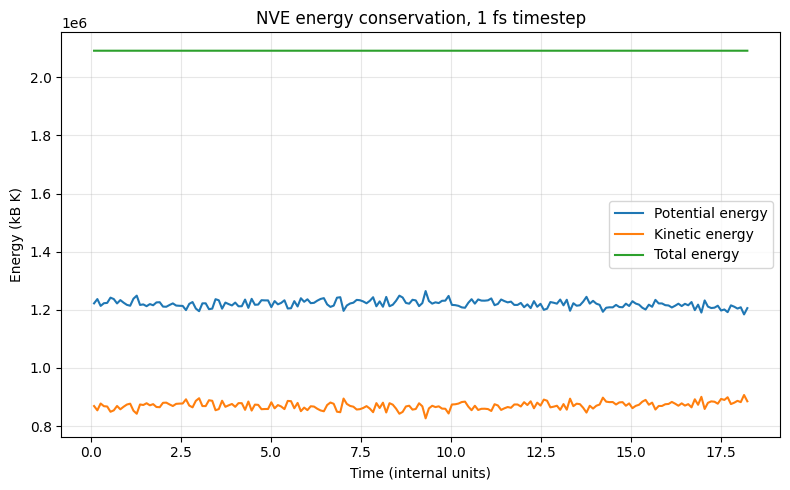

,Timestep (fs),Mean total energy,Energy slope,Relative drift / internal time,Relative bounded oscillation
0,1.0,2.091221e+06,-0.133443,-6.381095e-08,0.000005
1,0.5,2.091218e+06,-0.021845,-1.044604e-08,0.000001



Measured bounded-energy error ratio (1 fs / 0.5 fs) = 3.890
Expected ratio for second-order velocity-Verlet = 4.000


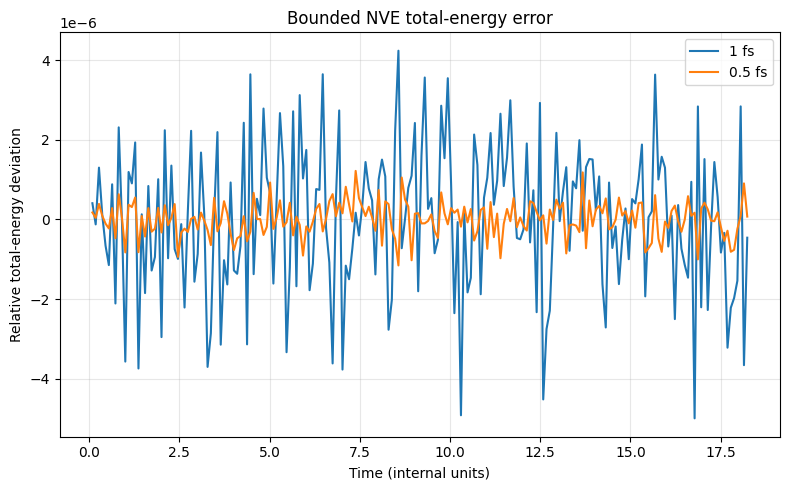

,Test,Relative error
0,Maximum particle force error,5.709060e-06
1,Virial error,1.360220e-09



Maximum force relative error = 5.709060e-06
Virial relative error        = 1.360220e-09
Finite-difference displacement = 1e-6 Angstrom
Accepted force tolerance       = 5e-05

Estimated absolute finite-difference force resolution = 4.336e-03

Finite-difference tolerance estimate
------------------------------------
Smallest tested analytical force = 1.359884e+02
Median tested analytical force   = 3.064184e+03
Absolute FD noise estimate        = 4.336366e-03
Worst estimated relative floor    = 3.188777e-05
Typical estimated relative floor  = 1.415178e-06
Observed maximum relative error   = 5.709060e-06
Chosen relative tolerance         = 5.000000e-05


,Population,Mean temperature (K),Standard deviation (K),Target temperature (K)
0,Whole system,293.009230,1.447977,293.0
1,CH3,292.884826,7.586759,293.0
2,CH2,292.847991,4.668150,293.0



Mean total-system temperature = 293.009 K
Mean CH3 temperature          = 292.885 K
Mean CH2 temperature          = 292.848 K

CH3 - CH2 mean temperature difference = 0.037 K


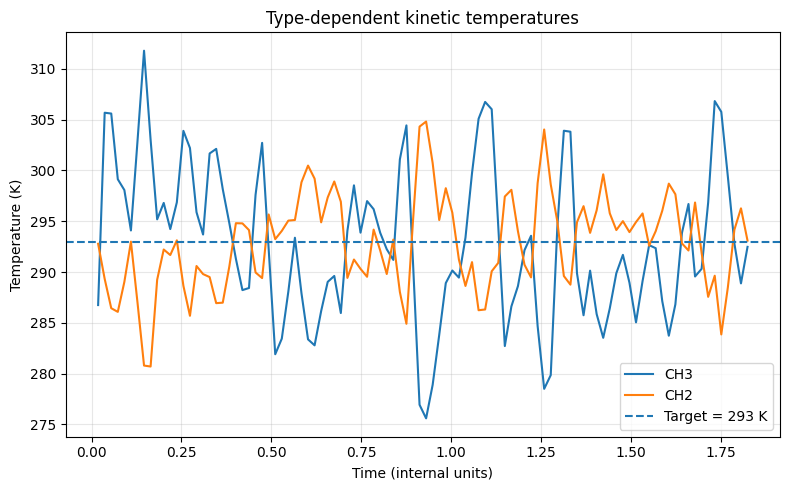

In [2]:
# B3: NVE energy conservation, finite-difference force test, temperature per site type

# --- Load the saved runs -------------------------------------------------
nve_1fs = load_csv("data/b3_nve_1fs.csv")
nve_05fs = load_csv("data/b3_nve_05fs.csv")
type_temp = load_csv("data/b3_type_temperature.csv")

print("1 fs columns :", list(nve_1fs.columns))
print("0.5 fs columns:", list(nve_05fs.columns))
print("Temperature-check columns:", list(type_temp.columns))


# --- Figure: energies of the 1 fs run ------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nve_1fs["time"], nve_1fs["Epot"], label="Potential energy")
ax.plot(nve_1fs["time"], nve_1fs["Ekin"], label="Kinetic energy")
ax.plot(nve_1fs["time"], nve_1fs["Etot"], label="Total energy")
ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Energy (kB K)")
ax.set_title("NVE energy conservation, 1 fs timestep")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- Systematic drift and bounded oscillation ----------------------------
result_1fs = energy_drift(nve_1fs["time"].to_numpy(float), nve_1fs["Etot"].to_numpy(float))
result_05fs = energy_drift(nve_05fs["time"].to_numpy(float), nve_05fs["Etot"].to_numpy(float))

energy_table = pd.DataFrame({
    "Timestep (fs)": [1.0, 0.5],
    "Mean total energy": [result_1fs["mean"], result_05fs["mean"]],
    "Energy slope": [result_1fs["slope"], result_05fs["slope"]],
    "Relative drift / internal time": [result_1fs["rel_drift"], result_05fs["rel_drift"]],
    "Relative bounded oscillation": [result_1fs["rel_oscillation"], result_05fs["rel_oscillation"]],
})
display(energy_table)

# Velocity-Verlet is second order: halving the step should reduce the bounded error by 4
ratio = result_1fs["rel_oscillation"] / result_05fs["rel_oscillation"]
print()
print(f"Measured bounded-energy error ratio (1 fs / 0.5 fs) = {ratio:.3f}")
print("Expected ratio for second-order velocity-Verlet = 4.000")


# --- Figure: bounded energy error after removing the drift ---------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nve_1fs["time"], result_1fs["residual"] / abs(result_1fs["mean"]), label="1 fs")
ax.plot(nve_05fs["time"], result_05fs["residual"] / abs(result_05fs["mean"]), label="0.5 fs")
ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Relative total-energy deviation")
ax.set_title("Bounded NVE total-energy error")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- Finite-difference force test: read the output of force_test.c -------
fd_text = Path("data/b3_force_test.txt").read_text(encoding="utf-16")

force_errors = [float(x) for x in re.findall(r"Particle .*?rel\.err=([0-9.eE+\-]+)", fd_text)]
virial_match = re.search(r"Virial test:.*rel\.err=([0-9.eE+\-]+)", fd_text)
if len(force_errors) == 0 or virial_match is None:
    raise ValueError("Force or virial errors not found in data/b3_force_test.txt")

max_force_error = max(force_errors)
virial_error = float(virial_match.group(1))

fd_table = pd.DataFrame({
    "Test": ["Maximum particle force error", "Virial error"],
    "Relative error": [max_force_error, virial_error],
})
display(fd_table)

print()
print(f"Maximum force relative error = {max_force_error:.6e}")
print(f"Virial relative error        = {virial_error:.6e}")
print("Finite-difference displacement = 1e-6 Angstrom")
print(f"Accepted force tolerance       = {FD_TOL:g}")


# --- Noise floor of the finite-difference test ---------------------------
# Rounding in U is about eps*|U|. Dividing by the step delta gives an ABSOLUTE force error.
delta = 1e-6
eps_machine = np.finfo(float).eps
U_scale = abs(nve_1fs["Epot"].mean())
force_noise = 16.0 * eps_machine * U_scale / delta

print()
print(f"Estimated absolute finite-difference force resolution = {force_noise:.3e}")

# Analytical force vectors that were tested (one row per particle: fx, fy, fz)
force_vectors = np.array(
    re.findall(
        r"Particle\s+\d+:\s+Force analytical:\s*"
        r"\(\s*([0-9.eE+\-]+)\s*,\s*([0-9.eE+\-]+)\s*,\s*([0-9.eE+\-]+)\s*\)",
        fd_text,
    ),
    dtype=float,
)
magnitudes = np.linalg.norm(force_vectors, axis=1)
magnitudes = magnitudes[magnitudes > 0]          # ignore exactly zero forces, if any

min_force = magnitudes.min()
median_force = np.median(magnitudes)

# The floor is absolute, so it is worst for the smallest force
worst_floor = force_noise / min_force
typical_floor = force_noise / median_force

print()
print("Finite-difference tolerance estimate")
print("------------------------------------")
print(f"Smallest tested analytical force = {min_force:.6e}")
print(f"Median tested analytical force   = {median_force:.6e}")
print(f"Absolute FD noise estimate        = {force_noise:.6e}")
print(f"Worst estimated relative floor    = {worst_floor:.6e}")
print(f"Typical estimated relative floor  = {typical_floor:.6e}")
print(f"Observed maximum relative error   = {max_force_error:.6e}")
print(f"Chosen relative tolerance         = {FD_TOL:.6e}")


# --- Mass check: temperature of each site type ---------------------------
mean_T_total = type_temp["T"].mean()
mean_T_ch3 = type_temp["T_CH3_K"].mean()
mean_T_ch2 = type_temp["T_CH2_K"].mean()

temperature_table = pd.DataFrame({
    "Population": ["Whole system", "CH3", "CH2"],
    "Mean temperature (K)": [mean_T_total, mean_T_ch3, mean_T_ch2],
    "Standard deviation (K)": [type_temp["T"].std(), type_temp["T_CH3_K"].std(), type_temp["T_CH2_K"].std()],
    "Target temperature (K)": [T_TARGET, T_TARGET, T_TARGET],
})
display(temperature_table)

print()
print(f"Mean total-system temperature = {mean_T_total:.3f} K")
print(f"Mean CH3 temperature          = {mean_T_ch3:.3f} K")
print(f"Mean CH2 temperature          = {mean_T_ch2:.3f} K")
print()
print(f"CH3 - CH2 mean temperature difference = {mean_T_ch3 - mean_T_ch2:.3f} K")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(type_temp["time"], type_temp["T_CH3_K"], label="CH3")
ax.plot(type_temp["time"], type_temp["T_CH2_K"], label="CH2")
ax.axhline(T_TARGET, linestyle="--", label="Target = 293 K")
ax.set_xlabel("Time (internal units)")
ax.set_ylabel("Temperature (K)")
ax.set_title("Type-dependent kinetic temperatures")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### B4) Bonded forces

Implement the bond, angle and torsion forces (both dihedrals of each
pentane molecule; one routine serves both).

### B5) Test the bonded forces

Finite-difference verification **per bonded term**, on a single molecule,
plus long-time NVE energy conservation for that single molecule.

Test the forces from a **thermalised** molecule, not from the one your
initialisation builds. A freshly built chain sits exactly at the minimum
of its bond, angle and torsion terms, so all three bonded forces are zero
there and the check compares round-off with round-off: it reports large
relative errors on perfectly correct code, and it would equally pass code
that is wrong. Run the molecule at the target temperature first and test
from that configuration.

Deliver:

- a **table** with one row per bonded term (bond, angle, torsion), giving
  the largest relative force error against finite differences;
- a **figure** of the energy of the single-molecule NVE run against time;
- the **check on the torsion**: the numerical values of the sum of the
  four torsion forces and of the net torque they produce, which should
  both be zero to round-off. Report the numbers, not the intention.

### Answer B4-B5: Bonded forces and their tests

#### B4: Implementation
- We implemented the bond, angle and dihedral forces in [`forces.c`](code/forces.c). They are `calculate_forces_bond`, `calculate_forces_angle` and `calculate_forces_dihedral`.
- The formulas are the ones derived in A2.
- One dihedral routine serves both torsions of the molecule (atoms 0-1-2-3 and 1-2-3-4).

#### B5a: Finite-difference test per term
- We used a single n-pentane molecule that we **thermalised** first. The freshly built chain sits at the minimum of all bonded terms, so all its bonded forces are zero.

| Bonded term | Largest relative force error |
|---|---:|
| Bond | $1.00916\times10^{-9}$ |
| Angle | $1.15294\times10^{-9}$ |
| Torsion | $2.11279\times10^{-8}$ |

- Our analytical forces agree with the numerical derivative of each potential to 8 or 9 digits.

#### B5b: Net force and net torque of the torsion
- Both must vanish up to round-off:

| Torsion | $\lvert\sum\mathbf F\rvert$ | $\lvert\boldsymbol\tau_\mathrm{net}\rvert$ |
|---|---:|---:|
| 0-1-2-3 | $1.77636\times10^{-15}$ | $7.90670\times10^{-13}$ |
| 1-2-3-4 | $2.92964\times10^{-14}$ | $3.37489\times10^{-13}$ |

- Relative to the size of the individual forces:

| Torsion | Relative force residual | Relative torque residual |
|---|---:|---:|
| 0-1-2-3 | $7.34\times10^{-18}$ | $2.32\times10^{-15}$ |
| 1-2-3-4 | $4.65\times10^{-17}$ | $3.81\times10^{-16}$ |

- **Conclusion:** the residuals are at round-off level. Our torsion conserves momentum and angular momentum.

#### B5c: Long NVE run of the single molecule
- We ran the same thermalised molecule for about 100 ps with a 1 fs time step. The figure is below.

| Quantity | Value |
|---|---:|
| Mean total energy | $1758.56843\ k_B\mathrm{K}$ |
| Relative systematic drift (linear fit) | $1.14\times10^{-9}\ \mathrm{ps}^{-1}$ |
| Relative bounded oscillation (half range after detrending) | $1.25\times10^{-4}$ |

- $E_\mathrm{kin}$ and $E_\mathrm{pot}$ trade energy while $E_\mathrm{tot}$ stays constant over the whole 100 ps.

#### Likely oral questions
- **Why thermalise before testing?** At the built structure all bonded forces are zero, so the test would compare round-off with round-off.
- **Why do the torsion forces sum to zero?** Translating or rotating the four atoms does not change $\phi$ (see A2, section 4).

First rows:


,step,time,Epot,Ekin,Etot,T,T_CH3_K,T_CH2_K
0,20,0.018236,26.609968,1731.944185,1758.554153,288.657364,487.250385,60.042896
1,40,0.036472,20.716715,1737.773636,1758.490351,289.628939,485.137318,62.747040
2,60,0.054708,15.573964,1742.941492,1758.515456,290.490249,463.130866,78.566421
3,80,0.072944,12.129966,1746.573752,1758.703719,291.095625,450.869083,87.548112
4,100,0.091180,7.384322,1751.112686,1758.497008,291.852114,429.683703,102.680350



Last rows:


,step,time,Epot,Ekin,Etot,T,T_CH3_K,T_CH2_K
4995,99920,91.107056,45.127859,1713.517025,1758.644883,285.586171,436.297793,89.916365
4996,99940,91.125292,16.499034,1742.004413,1758.503448,290.334069,470.792828,73.250207
4997,99960,91.143528,11.800026,1746.736183,1758.536208,291.122697,454.992903,84.834994
4998,99980,91.161764,-19.962453,1778.494385,1758.531932,296.415731,416.543325,117.525425
4999,100000,91.180000,21.313727,1737.357953,1758.671679,289.559659,448.841798,86.851680


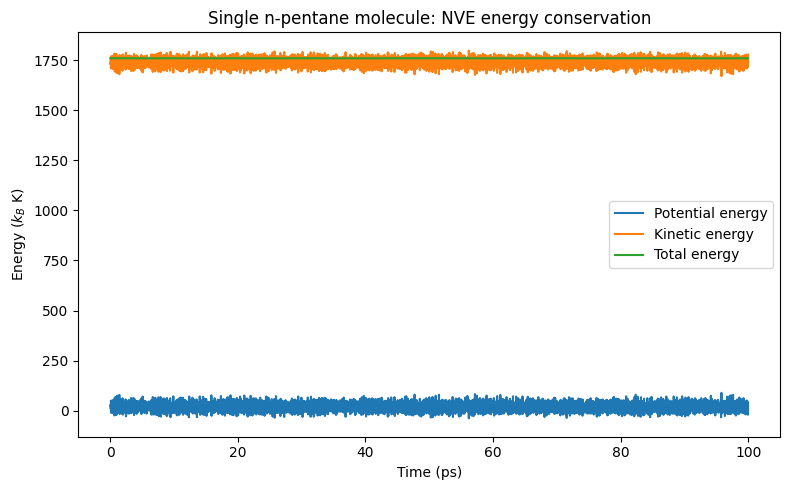


B5 NVE ENERGY CONSERVATION
Number of saved samples          = 5000
Simulation time                  = 99.977107 ps
Mean total energy                = 1758.56842961 kB K
Initial saved total energy       = 1758.5541532 kB K
Final total energy               = 1758.67167944 kB K
First-to-last energy change      = 1.175262e-01 kB K
Relative first-to-last change    = 6.683063e-05
Linear energy drift              = 2.006882e-06 kB K / ps
Relative linear drift            = 1.141202e-09 per ps
Total observed energy range      = 4.382659e-01 kB K
Relative observed energy range   = 2.492174e-04
Detrended half-range             = 2.190707e-01 kB K
Relative detrended half-range    = 1.245733e-04
Standard deviation of Etot       = 8.239123e-02 kB K
Relative standard deviation      = 4.685131e-05


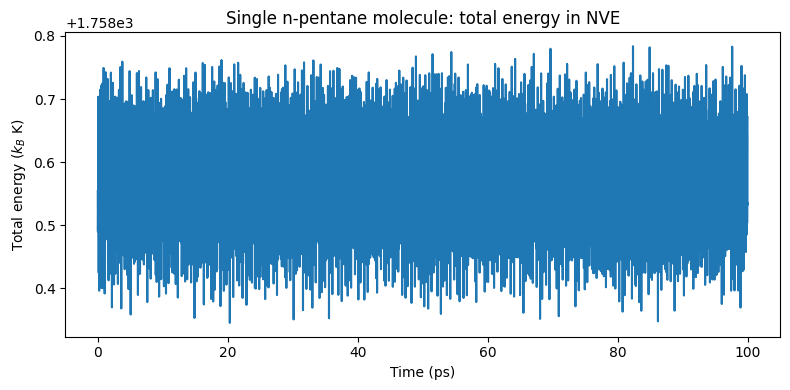

In [3]:
# B5: NVE energy conservation of a single n-pentane molecule

# --- Load the run --------------------------------------------------------
b5 = load_csv("data/b5_nve.csv")

print("First rows:")
display(b5.head())
print("\nLast rows:")
display(b5.tail())

b5["time_ps"] = b5["time"] * PS_PER_TIME_UNIT


# --- Figure: energies ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(b5["time_ps"], b5["Epot"], label="Potential energy")
plt.plot(b5["time_ps"], b5["Ekin"], label="Kinetic energy")
plt.plot(b5["time_ps"], b5["Etot"], label="Total energy")
plt.xlabel("Time (ps)")
plt.ylabel(r"Energy ($k_B$ K)")
plt.title("Single n-pentane molecule: NVE energy conservation")
plt.legend()
plt.tight_layout()
plt.show()


# --- Energy-conservation numbers -----------------------------------------
time = b5["time_ps"].to_numpy()
Etot = b5["Etot"].to_numpy()

drift = energy_drift(time, Etot)
mean_E = drift["mean"]

first_to_last = Etot[-1] - Etot[0]
energy_range = Etot.max() - Etot.min()
detrended_half_range = 0.5 * (drift["residual"].max() - drift["residual"].min())
energy_std = Etot.std(ddof=1)

print("\nB5 NVE ENERGY CONSERVATION")
print("=" * 60)
print(f"Number of saved samples          = {len(b5)}")
print(f"Simulation time                  = {time[-1] - time[0]:.6f} ps")
print(f"Mean total energy                = {mean_E:.12g} kB K")
print(f"Initial saved total energy       = {Etot[0]:.12g} kB K")
print(f"Final total energy               = {Etot[-1]:.12g} kB K")
print(f"First-to-last energy change      = {first_to_last:.6e} kB K")
print(f"Relative first-to-last change    = {first_to_last / mean_E:.6e}")
print(f"Linear energy drift              = {drift['slope']:.6e} kB K / ps")
print(f"Relative linear drift            = {drift['rel_drift']:.6e} per ps")
print(f"Total observed energy range      = {energy_range:.6e} kB K")
print(f"Relative observed energy range   = {energy_range / mean_E:.6e}")
print(f"Detrended half-range             = {detrended_half_range:.6e} kB K")
print(f"Relative detrended half-range    = {drift['rel_oscillation']:.6e}")
print(f"Standard deviation of Etot       = {energy_std:.6e} kB K")
print(f"Relative standard deviation      = {energy_std / mean_E:.6e}")


# --- Figure: total energy only, zoomed in --------------------------------
plt.figure(figsize=(8, 4))
plt.plot(b5["time_ps"], b5["Etot"])
plt.xlabel("Time (ps)")
plt.ylabel(r"Total energy ($k_B$ K)")
plt.title("Single n-pentane molecule: total energy in NVE")
plt.tight_layout()
plt.show()

### B6) Initialization

Devise a procedure to pack $N$ pentane molecules in a cubic box at the
target density with a sane starting structure (reasonable internal
geometry, and no overlap so severe that the first step throws a molecule
across the box), and assign velocities from the Maxwell-Boltzmann
distribution at the target temperature.

Deliver: a description of your procedure, the box size and $N$ you chose
with the arithmetic that connects them to $\rho = 626\ \mathrm{kg/m^3}$,
the **closest interacting pair distance** your configuration starts with
next to $\sigma$, and a **rendering** of the starting configuration. Open
it in OVITO and look at it, which is the point of the exercise; the figure
in your report may come from OVITO, from VMD, or from your own plot of the
`.pdb`, as long as it travels in the zip.

A lattice of chains is not a liquid, and a packing dense enough to hit the
target density will have pairs inside $\sigma$. That is expected. B7 is
where you measure what they cost.

### B7) Energy conservation of the full system

From the packed configuration, run NVE and check energy conservation.

Deliver a **figure** of $E_\mathrm{tot}$, $E_\mathrm{kin}$,
$E_\mathrm{pot}$ and $T$ against time, and an explanation of the initial
transient: the temperature moves within the first picoseconds even though
the total energy does not. Where does that kinetic energy come from, and
what does it tell you about your starting structure?

### Answer B6-B7: Initialisation and full-system NVE

#### B6: Initialisation

**System size**
- We use $N = 400$ molecules, which gives $400 \times 5 = 2000$ sites.
- Each molecule has two CH$_3$ and three CH$_2$ sites.

**Box size from the density**

| Step | Calculation | Result |
|---|---|---:|
| Mass of one molecule | $2(15.035) + 3(14.027)$ | 72.151 amu |
| Total mass | $400 \times 72.151 \times 1.66054\times10^{-27}$ | $4.7924\times10^{-23}$ kg |
| Volume | $m/\rho = 4.7924\times10^{-23} / 626$ | $7.6556\times10^{-26}$ m$^3$ |
| Box length | $L = V^{1/3}$ | $4.2461\times10^{-9}$ m = **42.461 Å** |

**Packing procedure**
- We put the 400 molecule centres on a $10\times10\times4$ grid.
- Each molecule is built all-trans, with $r_0 = 1.54$ Å and $\theta_0 = 114^\circ$, so its internal geometry is sane.
- We rotate the zig-zag plane of each molecule at random about its long axis.

**Velocities**
- We draw them from a Maxwell-Boltzmann distribution at 293 K, using the right mass for each site type.
- Then we remove the centre-of-mass momentum.

**Closest interacting pair**

| Quantity | Value |
|---|---:|
| Closest pair | CH$_2$-CH$_2$ |
| Distance $r_\mathrm{min}$ | 3.240 Å |
| $\sigma$ for this pair | 3.95 Å |
| $r_\mathrm{min}/\sigma$ | **0.820** |

- **Why is this expected?** The LJ energy is zero at $r = \sigma$ and strongly repulsive below it. A packing dense enough to reach 626 kg/m$^3$ always has some pairs inside $\sigma$.

**Rendering**
- The box is filled and has no catastrophic overlaps.
- The ordered arrangement is clearly not yet a liquid.

![B6 starting configuration](code/b6_render.png)

#### B7: NVE of the packed system
- We ran with a 1 fs time step for about 20 ps, with the thermostat off. The figure is below.

| Quantity | Value |
|---|---:|
| Relative drift (linear fit) | $-1.15\times10^{-5}\ \mathrm{ps}^{-1}$ |
| Total systematic change over 20 ps | about 0.023 % |
| Temperature after the transient | about 200-205 K |

- $E_\mathrm{tot}$ is approximately constant.

**The initial transient**
- The temperature starts at 293 K, drops during the first few ps, and then fluctuates around 200-205 K. The total energy does not change.
- Assigning velocities at 293 K only sets the initial kinetic energy. It does not make the configuration an equilibrium one.
- $E_\mathrm{tot} = E_\mathrm{kin} + E_\mathrm{pot}$ is constant, so energy moves between the two.
- In our run $E_\mathrm{pot}$ rises and $E_\mathrm{kin}$ falls, so $T$ falls.
- **Why does $T$ fall?** The temperature is proportional to the kinetic energy. The kinetic energy is not lost: it becomes potential energy.
- **What this says about our start:** it is a reasonable starting point, but it is an artificial grid structure and not an equilibrated liquid.

B7 NVE results
Simulation time: 19.999 ps
Mean total energy: -73747.483 kB K
Relative energy drift: -1.149e-05 per ps
Approximate systematic drift over the full run: -0.0230 %
Mean temperature over final 100 samples: 203.49 K


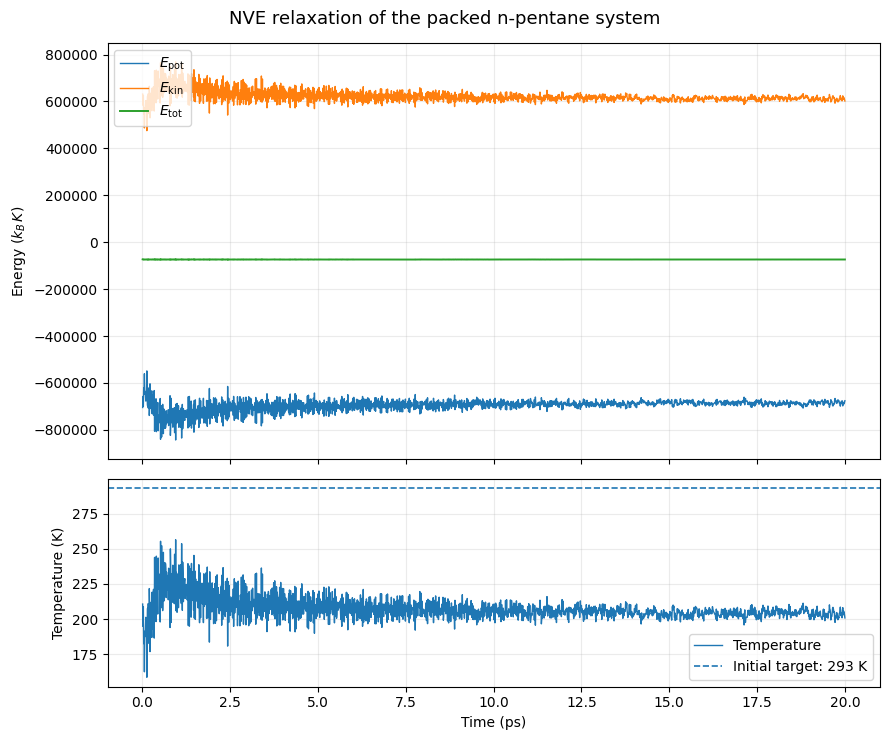

In [4]:
# B7: NVE energy conservation of the full pentane system

# --- Load the run --------------------------------------------------------
nve = load_csv("data/b7_nve.csv")
time_ps = nve["time"] * PS_PER_TIME_UNIT


# --- Energy-conservation numbers -----------------------------------------
drift = energy_drift(time_ps.to_numpy(), nve["Etot"].to_numpy())
total_change_percent = 100 * drift["rel_drift"] * time_ps.iloc[-1]
mean_T_final = np.mean(nve["T"].to_numpy()[-100:])

print("B7 NVE results")
print(f"Simulation time: {time_ps.iloc[-1]:.3f} ps")
print(f"Mean total energy: {drift['mean']:.3f} kB K")
print(f"Relative energy drift: {drift['rel_drift']:.3e} per ps")
print(f"Approximate systematic drift over the full run: {total_change_percent:.4f} %")
print(f"Mean temperature over final 100 samples: {mean_T_final:.2f} K")


# --- Figure: energies (top) and temperature (bottom) ---------------------
fig, (ax_energy, ax_temp) = plt.subplots(
    2, 1, figsize=(9, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

ax_energy.plot(time_ps, nve["Epot"], label=r"$E_{\mathrm{pot}}$", linewidth=1.0)
ax_energy.plot(time_ps, nve["Ekin"], label=r"$E_{\mathrm{kin}}$", linewidth=1.0)
ax_energy.plot(time_ps, nve["Etot"], label=r"$E_{\mathrm{tot}}$", linewidth=1.4)
ax_energy.set_ylabel(r"Energy ($k_B\,K$)")
ax_energy.legend()
ax_energy.grid(alpha=0.25)

ax_temp.plot(time_ps, nve["T"], label="Temperature", linewidth=1.0)
ax_temp.axhline(T_TARGET, linestyle="--", linewidth=1.2, label="Initial target: 293 K")
ax_temp.set_xlabel("Time (ps)")
ax_temp.set_ylabel("Temperature (K)")
ax_temp.legend()
ax_temp.grid(alpha=0.25)

fig.suptitle("NVE relaxation of the packed n-pentane system", fontsize=13)
plt.tight_layout()
plt.show()

### B8) Thermostat

Implement the Berendsen thermostat for NVT runs.

### B9) Test the thermostat

Starting from the packed configuration, run NVT and verify equilibration
to the target temperature.

Deliver:

- a **figure** of the temperature against time for NVE and for NVT, with
  **two values of the coupling time $\tau$**, on one set of axes;
- a **table** of the mean temperature and its fluctuation over the
  equilibrated part of each run, next to the target 293 K;
- a comment on the trade-off: what does a very short $\tau$ buy you, and
  what does it cost? What is the Berendsen thermostat *not* guaranteed to
  give you, however well it holds the mean temperature?

### Answer B8-B9: Thermostat and its test

#### B8: Berendsen thermostat
- **Where:** `thermostat()` in [`dynamics.c`](code/dynamics.c).
- **Step 1:** compute the current temperature from the kinetic energy:

$$T = \frac{2E_\mathrm{kin}}{3N - 3}.$$

- **Step 2:** multiply every velocity by the factor

$$\lambda = \sqrt{1 + \frac{\Delta t}{\tau_T}\left(\frac{T_0}{T} - 1\right)}.$$

- **Why this form?** We want the temperature to relax towards $T_0$ with time constant $\tau_T$, that is $\mathrm dT/\mathrm dt = (T_0 - T)/\tau_T$. Kinetic energy, and so $T$, scales with $\lambda^2$ when we scale velocities by $\lambda$. So one step needs $\lambda^2 T = T + \frac{\Delta t}{\tau_T}(T_0 - T)$. Dividing by $T$ gives the formula.
- **Meaning:**
  - If $T < T_0$, then $\lambda > 1$ and the system is heated.
  - If $T > T_0$, then $\lambda < 1$ and the system is cooled.

#### B9: Test
- We ran three simulations from the same packed start:
  - NVE (the run from B7),
  - NVT with $\tau = 0.01$ ps,
  - NVT with $\tau = 1.0$ ps.
- We computed the mean and the standard deviation of $T$ over the last 5 ps ($t \ge 15$ ps), after the initial relaxation. The figure and the table are below.

| Run | Mean $T$ (K) | Std of $T$ (K) | Target (K) |
|---|---:|---:|---:|
| NVE | 204.07 | 2.61 | 293 |
| NVT, $\tau = 0.01$ ps | 292.99 | 1.62 | 293 |
| NVT, $\tau = 1.0$ ps | 291.67 | 3.52 | 293 |

- **NVE** stays far below the target, consistent with B7.
- **Both NVT runs** approach 293 K.

#### Trade-off of the coupling time
| | Short $\tau$ (0.01 ps) | Long $\tau$ (1.0 ps) |
|---|---|---|
| Equilibration | fast | slow |
| Temperature fluctuation | small (1.62 K) | larger (3.52 K) |
| Disturbance of the dynamics | strong, because velocities are rescaled aggressively | weak |

#### What Berendsen does not guarantee
- It does **not** guarantee the correct canonical (NVT) ensemble.
- The mean temperature can be right while the distribution and the size of the temperature and energy fluctuations are wrong.
- Strong coupling suppresses the fluctuations artificially.

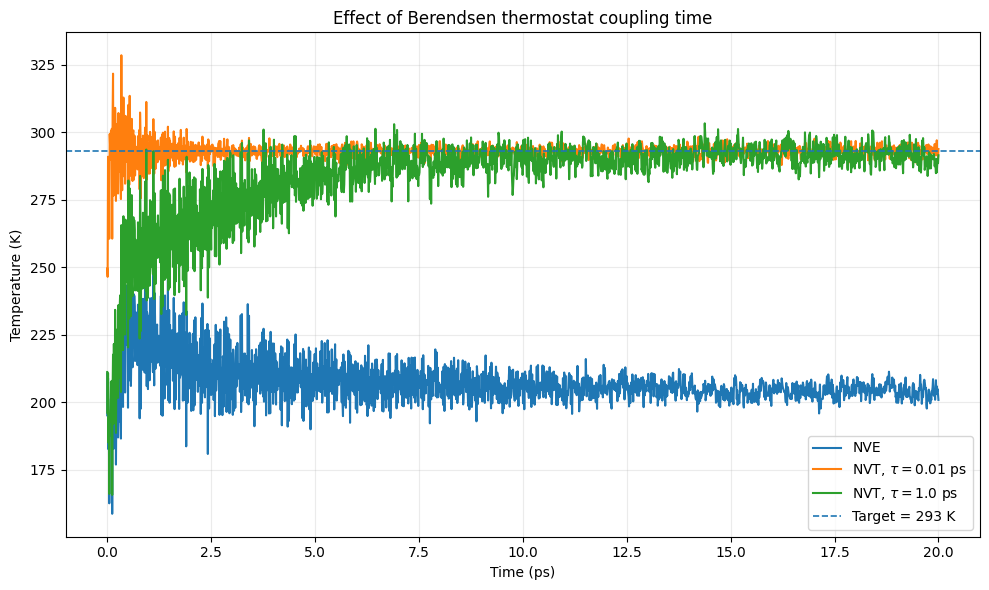

Temperature statistics calculated over the final 5 ps (t >= 15 ps):


,Run,Target T (K),Mean T (K),"Temperature fluctuation, std (K)"
0,NVE,293.0,204.07,2.61
1,"NVT, tau = 0.01 ps",293.0,292.99,1.62
2,"NVT, tau = 1.0 ps",293.0,291.67,3.52


In [5]:
# B9: Berendsen thermostat test (NVE versus NVT with two coupling times)

# --- Load the three runs and convert time to ps --------------------------
nve = load_csv("data/b7_nve.csv")
nvt_fast = load_csv("data/b9_nvt_tau001.csv")
nvt_slow = load_csv("data/b9_nvt_tau1.csv")

nve["time_ps"] = nve["time"] * PS_PER_TIME_UNIT
nvt_fast["time_ps"] = nvt_fast["time"] * PS_PER_TIME_UNIT
nvt_slow["time_ps"] = nvt_slow["time"] * PS_PER_TIME_UNIT


# --- Figure: temperature against time ------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(nve["time_ps"], nve["T"], label="NVE")
plt.plot(nvt_fast["time_ps"], nvt_fast["T"], label=r"NVT, $\tau = 0.01$ ps")
plt.plot(nvt_slow["time_ps"], nvt_slow["T"], label=r"NVT, $\tau = 1.0$ ps")
plt.axhline(T_TARGET, linestyle="--", linewidth=1.2, label="Target = 293 K")
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.title("Effect of Berendsen thermostat coupling time")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# --- Statistics over the final 5 ps of each run --------------------------
EQUILIBRATED_FROM_PS = 15.0

T_nve = nve.loc[nve["time_ps"] >= EQUILIBRATED_FROM_PS, "T"]
T_fast = nvt_fast.loc[nvt_fast["time_ps"] >= EQUILIBRATED_FROM_PS, "T"]
T_slow = nvt_slow.loc[nvt_slow["time_ps"] >= EQUILIBRATED_FROM_PS, "T"]

results = pd.DataFrame({
    "Run": ["NVE", "NVT, tau = 0.01 ps", "NVT, tau = 1.0 ps"],
    "Target T (K)": [T_TARGET, T_TARGET, T_TARGET],
    "Mean T (K)": [T_nve.mean(), T_fast.mean(), T_slow.mean()],
    "Temperature fluctuation, std (K)": [T_nve.std(ddof=1), T_fast.std(ddof=1), T_slow.std(ddof=1)],
}).round(2)

print("Temperature statistics calculated over the final 5 ps (t >= 15 ps):")
display(results)

## Part C: Production runs and analysis

*In the oral you should be able to:* predict how each observable moves
when temperature, density or a force-field parameter changes; explain the
pentane effect from the force field; defend where your MSD fit starts and
your error estimate for $D$.

Part C is measurement, so every number needs an uncertainty and every
figure needs axis labels with units, a legend, and a sentence stating
what the reader should conclude.

**Equilibrate before you sample, and check that you did.** Both
measurements below have their own relaxation time, and neither is short:
the conformer populations relax over tens of picoseconds, and so does the
sharing of kinetic energy between the chain ends and the chain interior
after the starting lattice melts. Sampling from a configuration that is
still relaxing biases the answer in a direction you can predict but will
not see. Discard enough of the beginning of each production run that the
quantity you are about to measure has stopped drifting, and say in your
report how you decided how much was enough.

### C1) Conformational analysis: the two dihedrals of pentane

Pentane has two coupled torsion angles $(\phi_1, \phi_2)$. Classify each
as *trans* ($t$, near $180^\circ$) or *gauche* ($g^+$ or $g^-$, near
$\pm 60^\circ$) and measure the populations of the *pair* states.

Deliver:

- a **figure**: the joint distribution of $(\phi_1,\phi_2)$ as a 2D
  histogram, with the state regions identifiable;
- a **figure**: the one-dimensional distribution of a single dihedral,
  with the *trans* and *gauche* minima marked;
- a **table** of the pair-state populations. Think about which states are
  equivalent by symmetry before you present nine numbers, and give each
  population an error estimate;
- **the pentane effect:** compare $g^+g^+$ with $g^+g^-$ explicitly.
  Explain the difference *from the force field*: which interaction
  penalises $g^+g^-$, and what happens geometrically to the two end
  groups in that conformation?
- **convergence:** the barriers are several $k_BT$, so transitions are
  rare events. Estimate, or measure from your trajectory, the mean time a
  molecule spends in a state, and use it to argue how long a run must be
  for the populations to be converged. Compare that with the length of
  the run you actually did, and say honestly whether your populations are
  converged.

*Results and discussion (C1):* …

In [6]:
# C1: joint (phi1, phi2) histogram, single-dihedral distribution, pair-state table

### C2) Diffusion coefficient

Implement creation and on-the-fly updating of the mean squared
displacement of the *molecular centres of mass*, and extract the
self-diffusion coefficient $D$ from the long-time slope,
$\langle \Delta r^2 \rangle \to 6Dt$.

Deliver:

- a **figure** of the MSD against time on log-log axes, with the
  ballistic ($\propto t^2$) and diffusive ($\propto t$) regimes marked,
  and the fit window shown;
- **the value of $D$** in internal units and in $\mathrm{m^2/s}$, with an
  **error estimate** and a statement of how you obtained it (for example
  by splitting the trajectory into blocks and comparing);
- a sentence justifying where your fit window starts and ends: why not
  earlier, why not later?

Then compare your $D$ with an experimental value for liquid pentane if
you can find one, and say what a disagreement would mean: an error in
your code, or a limitation of the model?

*Results (C2):* $D$ = … (internal) = … m²/s; fit window …; error …

In [7]:
# C2: MSD vs time (log-log), fit window, D extraction with error estimate

## Lessons learned

What would you do differently if you started over? What surprised you?
What in your results still bothers you? (Standing questions in the oral,
so write the honest version.)

*Lessons learned:* …

## Hand-in

One zip per group, layout exactly:

```
<group>_A2.zip
├── A2.ipynb     this notebook, filled in and executed
│                (all outputs present; task cells untouched)
├── A2.html      python3 nb2html.py A2.ipynb
├── code/        all .c/.h + README.md; must build with
│                gcc -O3 *.c -o md -lm    (no binaries)
└── data/        every data file this notebook loads
```

Long production runs are done in the terminal; record the exact commands
in the *Build & run log* and let the notebook load the saved output from
`data/`. Handed in executed, the notebook must open and display without
rerunning anything.

Write the path of every data file your notebook opens out in full, as
`"data/run.csv"` rather than assembling it from a variable. The checker
below looks for those paths literally, and it will report a file as
missing if it cannot see the name.

**Before you submit,** check your own zip:

```
python3 check_my_submission.py <group>_A2.zip --release A2.ipynb
```

where `--release` is a freshly downloaded, unmodified `A2.ipynb`. It
verifies the layout, that the task cells are untouched, that every cell
has been executed, that your C code compiles, and that every path and
link in the notebook is relative and present in the zip. Fix what it
reports, then submit. Setting up the Python environment
(`requirements.txt`, both helper scripts) is described on the Canvas page
*Working on the assignments*.